In [89]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub


In [90]:
path = kagglehub.dataset_download("shambhurajejagadale/student-performance-prediction-dataset")
print(path)

C:\Users\ADMIN\.cache\kagglehub\datasets\shambhurajejagadale\student-performance-prediction-dataset\versions\1


In [91]:
os.listdir(path)

['student_dataset_10000_rows.csv']

In [92]:
data = pd.read_csv(os.path.join(path, 'student_dataset_10000_rows.csv'))
df = pd.DataFrame(data)
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [93]:
df.shape

(10000, 8)

In [94]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


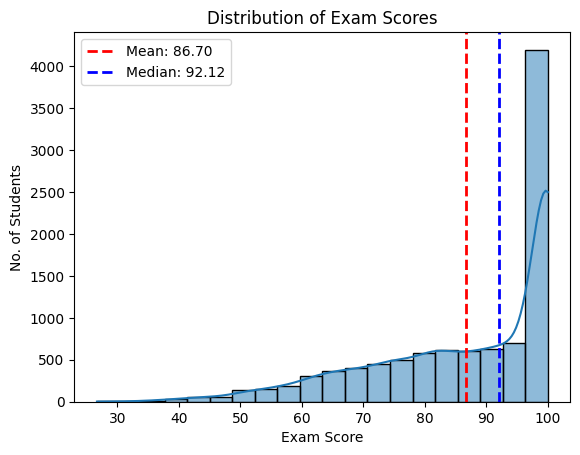

In [95]:
mean_score = df['exam_score'].mean()
median_score = df['exam_score'].median()
sns.histplot(df['exam_score'],bins=20, kde=True)
plt.axvline(mean_score, color='red',linewidth=2,linestyle='--', label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='blue',linewidth=2,linestyle='--', label=f'Median: {median_score:.2f}')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('No. of Students')
plt.legend()
plt.show()


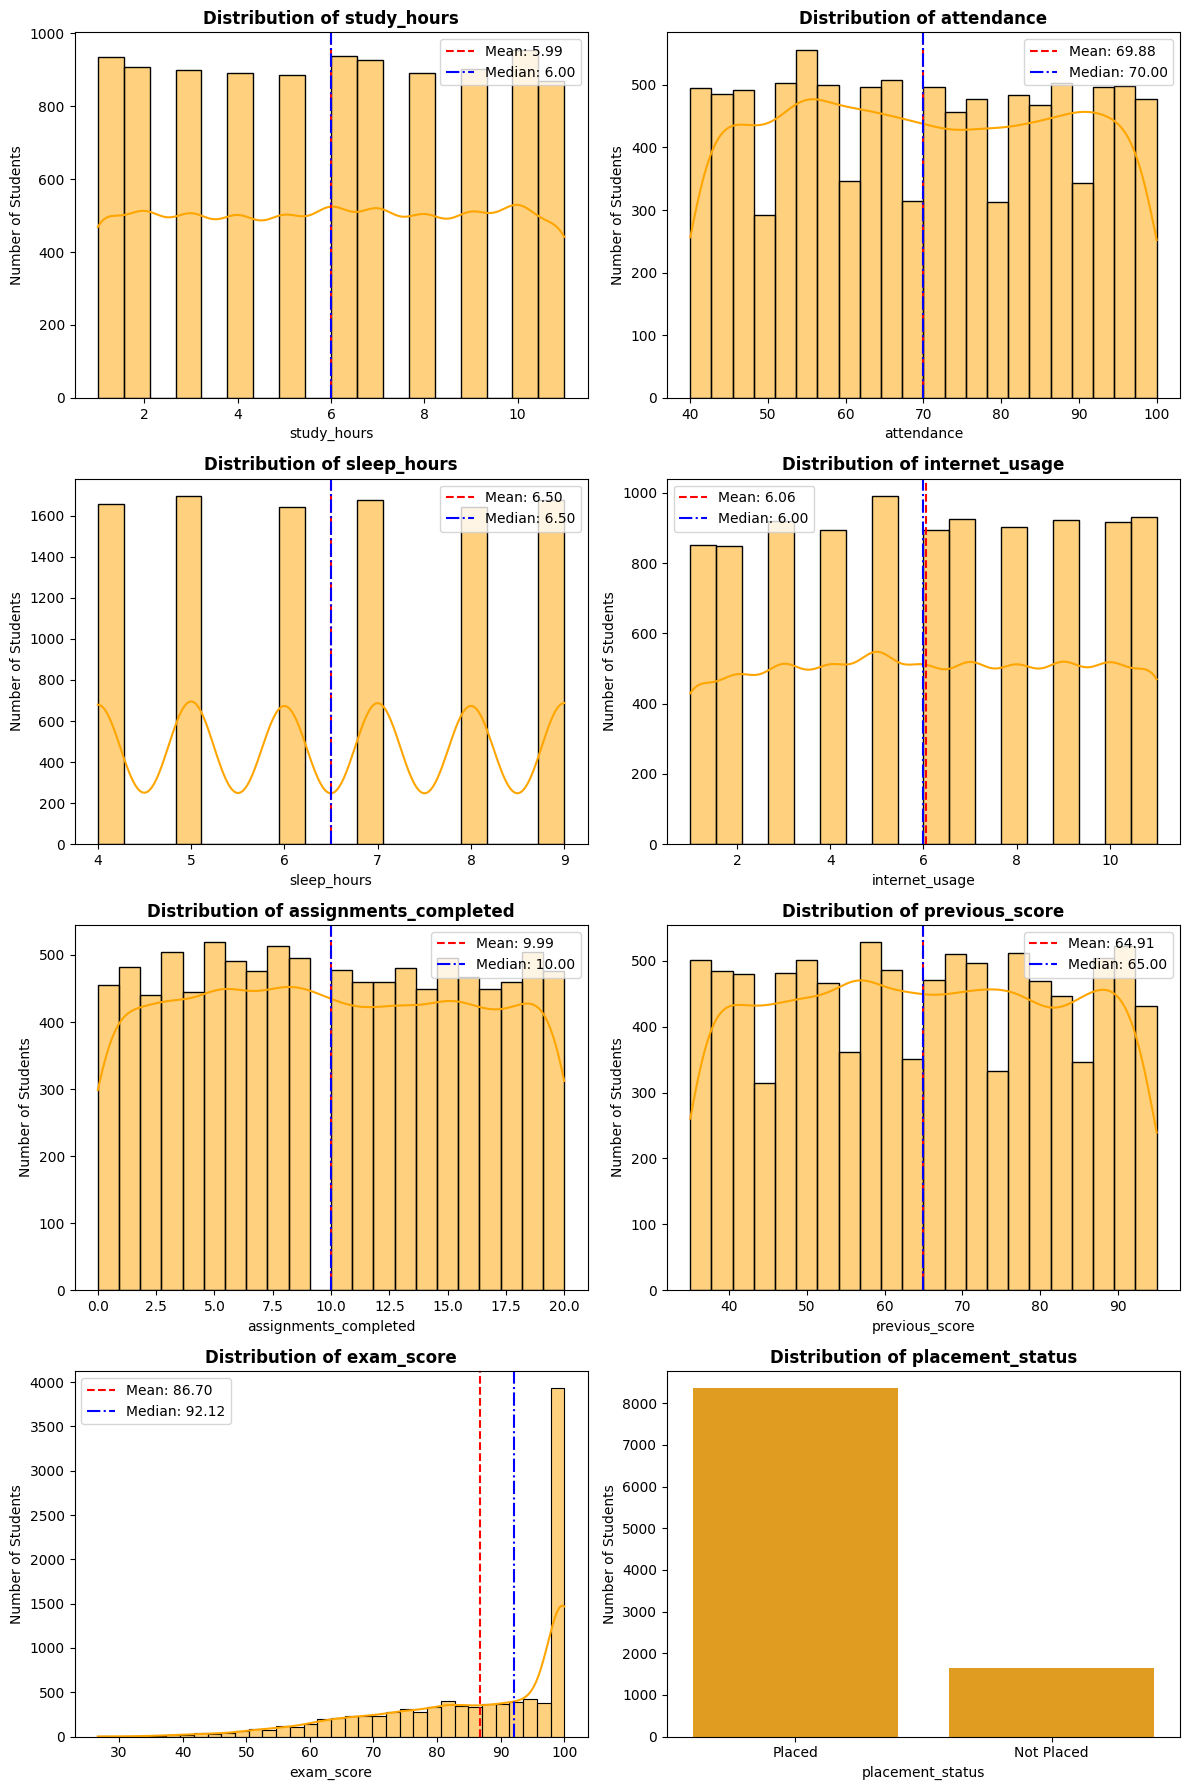

In [96]:
plt.figure(figsize=(12,18))

col = [
    'study_hours',
    'attendance',
    'sleep_hours',
    'internet_usage',
    'assignments_completed',
    'previous_score',
    'exam_score',
    'placement_status'
]


for i, col in enumerate(num_cols, 1):
    
    plt.subplot(4, 2, i)
    if pd.api.types.is_numeric_dtype(df[col]):
    
        mean_score = df[col].mean()
        median_score = df[col].median()
        sns.histplot(
            data=df,
            x=col,
            color='orange',
            kde=True
        )
        plt.axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
        plt.axvline(median_score, color='blue', linestyle='-.', label=f'Median: {median_score:.2f}')
        plt.legend()
    else:
        sns.countplot(
            data=df,
            x=col,
            color='orange'
        
        )

    plt.ylabel('Number of Students')
    plt.title("Distribution of " + col, fontweight='bold')


plt.tight_layout()
plt.show()


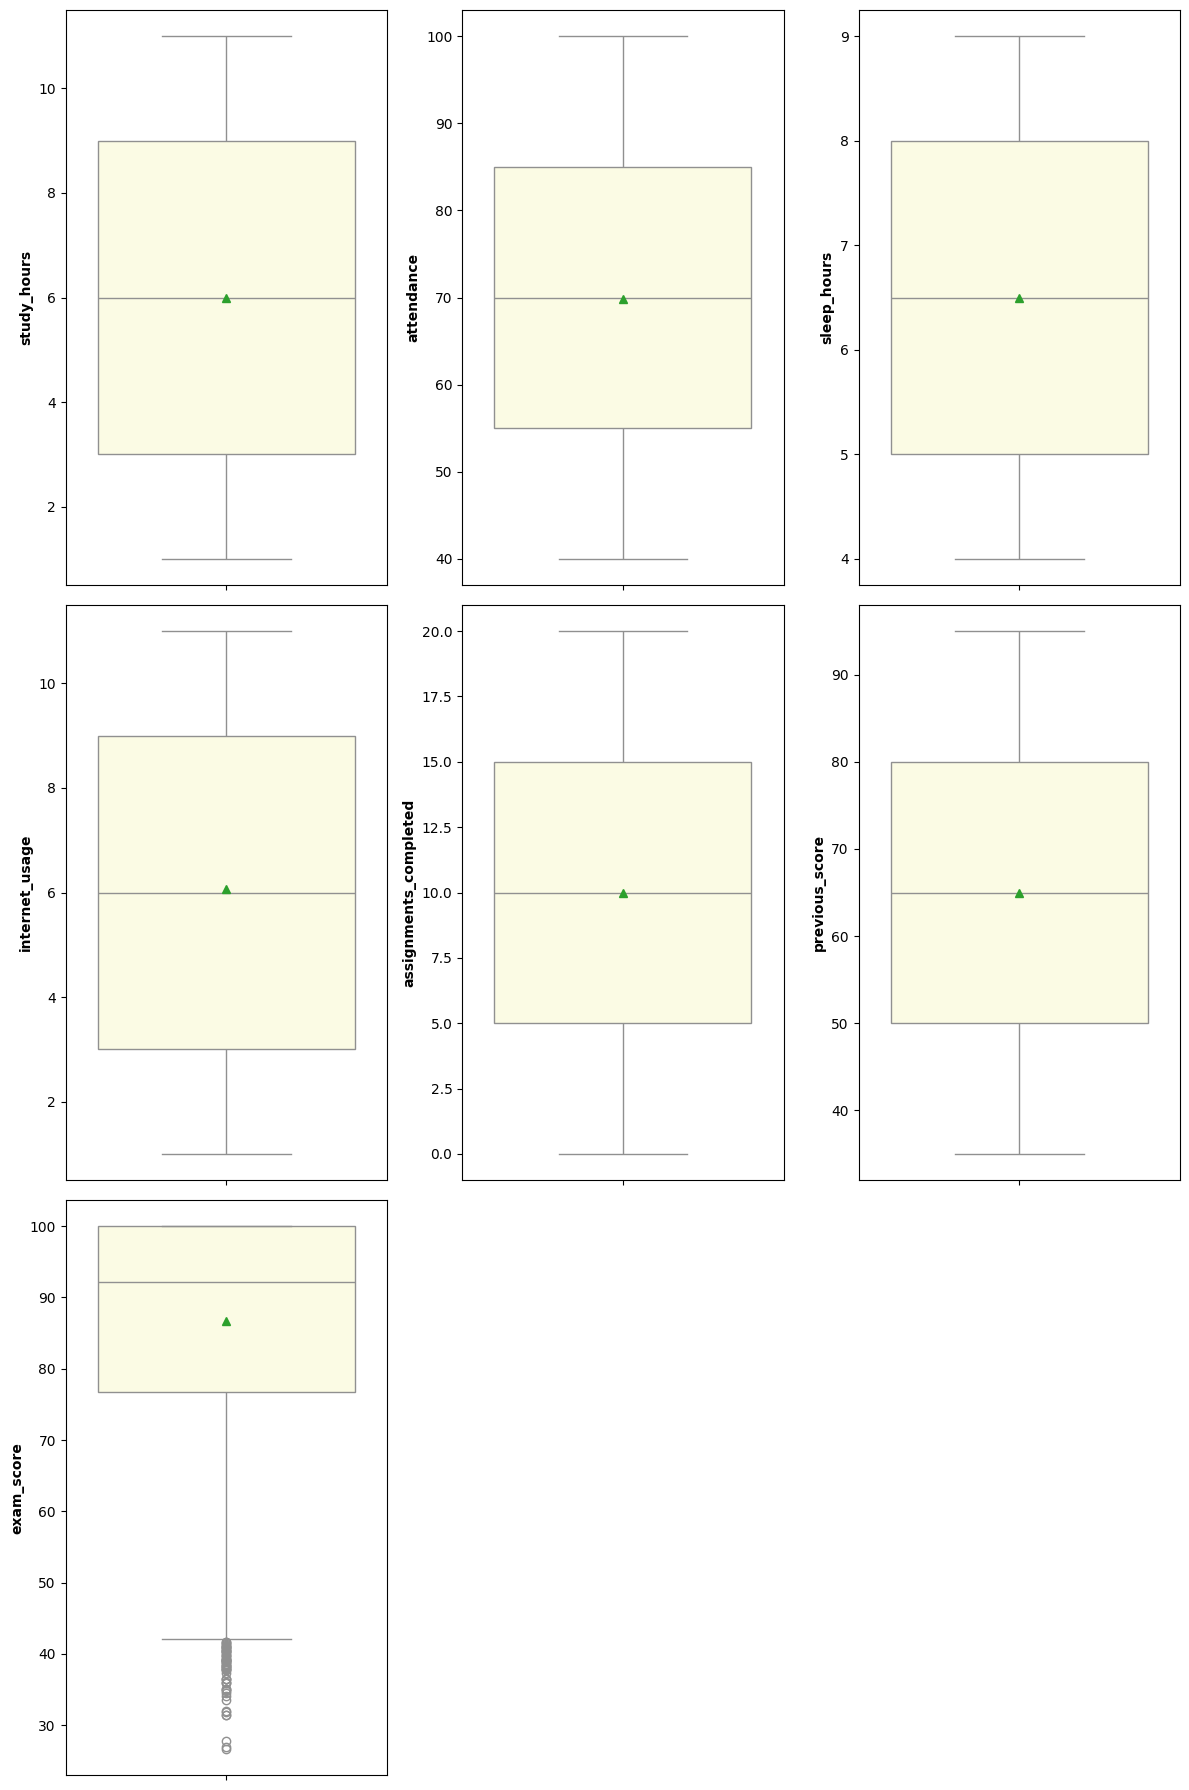

In [111]:
plt.figure(figsize=(12,18))

num_cols = [
    'study_hours',
    'attendance',
    'sleep_hours',
    'internet_usage',
    'assignments_completed',
    'previous_score',
    'exam_score'
]


for i, col in enumerate(num_cols, 1):
    
    plt.subplot(3, 3, i)
    
    sns.boxplot(
        data=df,
        y=col,
        color='lightyellow',
        showmeans=True,
        
    )
    plt.ylabel(col, fontweight='bold')   

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

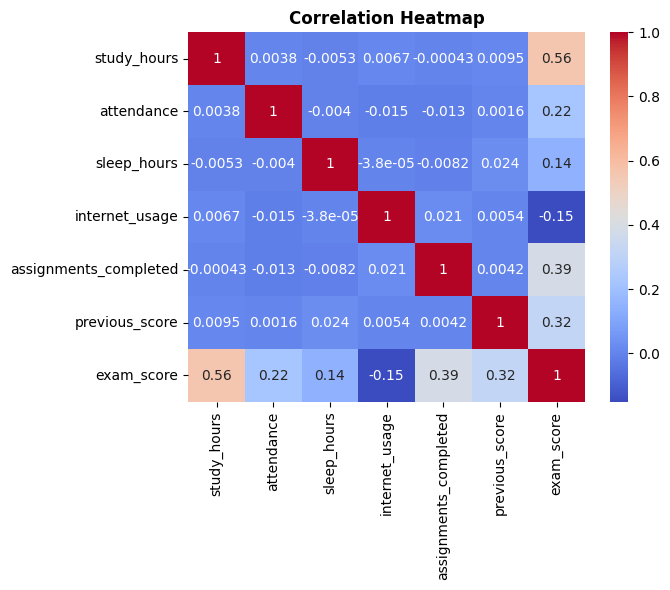

In [113]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap", fontweight='bold')

In [115]:
df.groupby("placement_status").mean()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
placement_status,,,,,,,
Not Placed,3.130170,62.865572,6.072384,6.842457,6.177616,55.729319,59.804653
Placed,6.552178,71.265558,6.582336,5.909167,10.738152,66.717449,91.996556
